# 03 | Temporal, calibration và provenance

Lý do DEV-only chọn luật → subject-level metrics + CI → stream continuity → calibration → integrity and model/runtime contract.

**Nguồn:** [HealthSense MachineLearning Lab](https://github.com/HealthSense-IUH/HealthSense-MachineLearning-Lab) ở commit chốt trong manifest. **Chỉ đọc artifact**, không fit lại model và không ghi đè freeze.

In [1]:
import sys
from pathlib import Path
import os
_candidates=[Path.cwd(), Path.cwd()/'notebooks'/'HealthSense_Defense_Evidence_Notebooks', Path.cwd()/'HealthSense_Defense_Evidence_Notebooks']
if os.getenv('HEALTHSENSE_NOTEBOOK_DIR'): _candidates.insert(0,Path(os.environ['HEALTHSENSE_NOTEBOOK_DIR']).expanduser())
for _p in _candidates:
    if (_p/'healthsense_evidence_utils.py').is_file(): sys.path.insert(0,str(_p.resolve())); break
from healthsense_evidence_utils import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print('REPO:',ROOT,'\nOUT:',OUT)
print('GIT:',git_info())

REPO: /home/phuc/Documents/HealthSense_rungtamnhi 
OUT: /home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T060119_214248Z
GIT: {'head': '1b9d9094cddb6f7fbe95e1f31fd969f0c537e22e', 'status_porcelain': '?? ": update README with V5 V6 datasets and references\\""\n?? experiments/02_beat_detector/official_detector_results.csv\n?? experiments/02_beat_detector/official_detector_summary.csv\n?? experiments/02_beat_detector/run_official_detectors.m\n?? experiments/02_beat_detector/score_official_detectors.py\n?? experiments/02_beat_detector/test_msptdfast.m\n?? experiments/02_beat_detector/test_msptdfast_peaks.csv\n?? experiments/02_beat_detector/test_ppg.csv\n?? experiments/02_beat_detector/test_qppgfast.m\n?? experiments/02_beat_detector/test_qppgfast_peaks.csv\n?? experiments/06_external_validation/audit_liu_dataset.py\n?? experiments/06_external_validation/audit_liu_signal.py\n?? experiments/06_external_validation/deepbeat_duplicate_overlap_audit.py\n?

## 1. Freeze contract là nguồn chân lý của notebook
Không nâng exploratory candidate thành clinical rule; không đồng nhất model nghiên cứu và model đang chạy trong AI Service.

In [2]:
A=EVIDENCE_PREFIX
freeze=js(A+'V6_RESEARCH_FREEZE_STATUS.json');rule=js(A+'FROZEN_GLOBAL_RULE_V2.json');meta=js('models/multidomain/healthsense_af_v6c_stacking.json');protocol=js(A+'protocol_metadata.json');display(pd.DataFrame({'key':['model','feature_count','raw_proba','rule_status','external:MIMIC_III_Ext_PPG','external:TriggersAF'],'value':[freeze['primary_model'],freeze['feature_schema']['n_features'],freeze['probability_output']['primary'],freeze['subject_alert_rule']['status'],freeze['external_validation']['MIMIC_III_Ext_PPG'],freeze['external_validation']['TriggersAF']]}));assert meta['features']==freeze['feature_schema']['features']==protocol['model_features']
assert meta['sha256'] in (ROOT/(A+'locked_inputs_SHA256.txt')).read_text(); print('Contract consistent: 14 feature names/order, sha metadata, and research freeze')

,key,value
0,model,models/multidomain/healthsense_af_v6c_stacking...
1,feature_count,14
2,raw_proba,raw meta_probability
3,rule_status,EXPLORATORY_CANDIDATE_FOR_SEALED_VALIDATION
4,external:MIMIC_III_Ext_PPG,PENDING_ACCESS_NOT_USED
5,external:TriggersAF,PENDING_ACCESS_NOT_USED


Contract consistent: 14 feature names/order, sha metadata, and research freeze


## 2. Tại sao chọn Global Rule V2?
Tìm các ứng viên trên **DEV only** và dùng ràng buộc sensitivity trước khi tối ưu balanced accuracy / specificity. Repository GitHub không commit toàn bộ DEV grid CSV, nên biểu đồ này **chỉ hiển thị kết quả của cấu hình được chọn**, không dựng một đường so sánh grid giả.

Selection: DEV_ONLY


,constraint,value
0,Macro sensitivity >=,0.850000
1,Each dataset sensitivity >=,0.750000
2,Selected macro sensitivity,0.861111
3,Selected macro specificity,0.896296
4,Selected balanced accuracy,0.878704


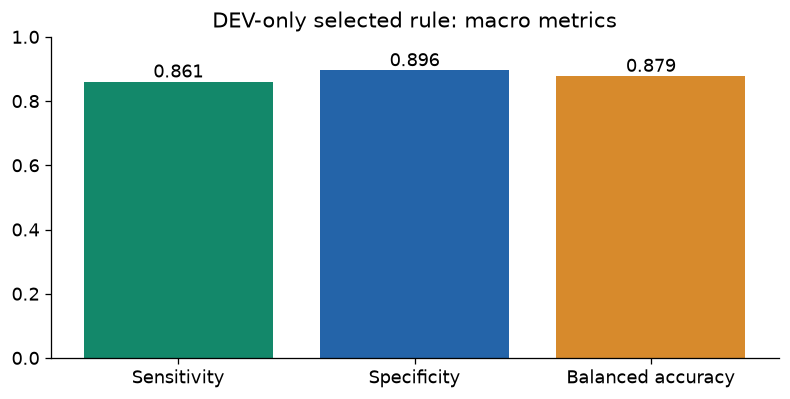

Base {'probability_threshold': 0.8, 'uncertainty_threshold': 0.05, 'min_consecutive': 5} Rescue {'probability_threshold': 0.9, 'uncertainty_threshold': 0.05, 'min_consecutive': 2} Stream policy: consecutive windows must belong to the same verified stream; gaps reset persistence


In [3]:
constraints=rule['constraints'];dev=rule['development_metrics'];print('Selection:',rule['selection_data']);display(pd.DataFrame([{'constraint':'Macro sensitivity >=','value':constraints['macro_sensitivity_min']},{'constraint':'Each dataset sensitivity >=','value':constraints['per_dataset_sensitivity_min']},{'constraint':'Selected macro sensitivity','value':dev['macro_sensitivity']},{'constraint':'Selected macro specificity','value':dev['macro_specificity']},{'constraint':'Selected balanced accuracy','value':dev['macro_balanced_accuracy']}]))
assert dev['macro_sensitivity']>=constraints['macro_sensitivity_min'];assert dev['min_dataset_sensitivity']>=constraints['per_dataset_sensitivity_min']
fig,ax=plt.subplots(figsize=(7,3.6));vals=[dev['macro_sensitivity'],dev['macro_specificity'],dev['macro_balanced_accuracy']];ax.bar(['Sensitivity','Specificity','Balanced accuracy'],vals,color=[GREEN,BLUE,ORANGE]);ax.set_ylim(0,1);ax.set_title('DEV-only selected rule: macro metrics');[ax.text(i,v,f'{v:.3f}',ha='center',va='bottom') for i,v in enumerate(vals)];figure(fig,'01_selected_dev_rule')
print('Base',rule['base'],'Rescue',rule['rescue'],'Stream policy:',rule['stream_policy'])

## 3. Tính liên tục của tín hiệu: verified stream coverage
Tỷ lệ rows có thể thuộc stream dài tối thiểu 5 windows là **coverage**, không phải sensitivity của alert. Window không liên tục không được cộng gộp tùy ý.

,dataset,split,rows,subjects,streams,median_stream_windows,p95_stream_windows,max_stream_windows,rows_in_stream_ge_2,rows_in_stream_ge_3,rows_in_stream_ge_5
0,deepbeat,dev,4026,13,1011,2.0,13.50,70,0.889717,0.795827,0.646051
1,deepbeat,test,1363,7,376,1.0,19.25,39,0.851798,0.768158,0.625825
2,pulsewatch,dev,17679,16,4796,2.0,10.00,20,0.896261,0.807229,0.666101
3,pulsewatch,test,30158,16,7804,2.0,9.00,23,0.907520,0.824292,0.688772
4,liu,dev,997,7,306,2.0,11.00,69,0.868606,0.708124,0.526580
5,liu,test,920,7,147,2.0,24.40,165,0.929348,0.857609,0.772826


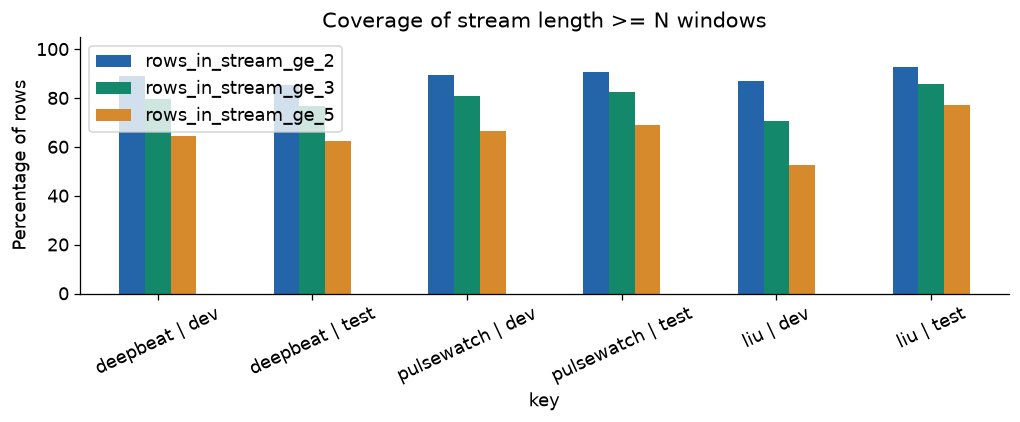

In [4]:
streams=csv(A+'verified_stream_summary.csv');display(streams)
fig,ax=plt.subplots(figsize=(9,3.8));x=streams.assign(key=streams.dataset+' | '+streams.split).set_index('key');(100*x[['rows_in_stream_ge_2','rows_in_stream_ge_3','rows_in_stream_ge_5']]).plot.bar(ax=ax,color=[BLUE,GREEN,ORANGE]);ax.set_ylim(0,105);ax.set_ylabel('Percentage of rows');ax.set_title('Coverage of stream length >= N windows');ax.tick_params(axis='x',rotation=25);figure(fig,'02_verified_stream_coverage')
assert (streams.rows_in_stream_ge_2>=streams.rows_in_stream_ge_3).all();assert (streams.rows_in_stream_ge_3>=streams.rows_in_stream_ge_5).all()

## 4. Reused TEST subject-alert: tái tính confusion và báo cỡ mẫu
Kết quả là exploratory. **Không** suy ra đã cải thiện so với một baseline khác nếu thiếu cùng protocol/split và subject-level paired comparison.

,dataset,evaluation,TP,TN,FP,FN,N,sensitivity,specificity,accuracy,precision,F1,balanced_accuracy
0,deepbeat,REUSED_TEST_EXPLORATORY,5,2,0,0,7,1.0,1.0,1.000000,1.0,1.0,1.00
1,pulsewatch,REUSED_TEST_EXPLORATORY,4,12,0,0,16,1.0,1.0,1.000000,1.0,1.0,1.00
2,liu,REUSED_TEST_EXPLORATORY,4,1,1,1,7,0.8,0.5,0.714286,0.8,0.8,0.65


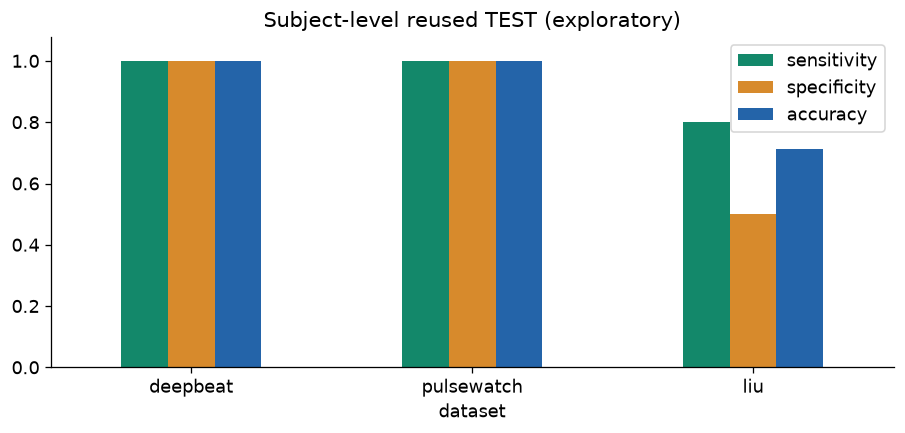

PosixPath('/home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T060119_214248Z/03_exploratory_subject_metrics.png')

In [5]:
summary=csv(A+'global_rule_v2_reused_test_summary.csv');r=[]
for _,v in summary.iterrows():
    q=confusion_metrics(v.TP,v.TN,v.FP,v.FN);assert_close(q['sensitivity'],v.sensitivity);assert_close(q['specificity'],v.specificity);assert_close(q['accuracy'],v.accuracy)
    r.append({'dataset':v.dataset,'evaluation':v.evaluation,**q})
subj=pd.DataFrame(r);table(subj,'03_subject_alert_confusion')
fig,ax=plt.subplots(figsize=(8,3.9));subj.set_index('dataset')[['sensitivity','specificity','accuracy']].plot.bar(ax=ax,color=[GREEN,ORANGE,BLUE]);ax.set_ylim(0,1.08);ax.tick_params(axis='x',rotation=0);ax.set_title('Subject-level reused TEST (exploratory)');figure(fig,'03_exploratory_subject_metrics')

## 5. Confidence interval: vì sao 5/5 ≠ chắc chắn 100%
CIs được đọc từ locked artifact. Wilson và exact đều là intervals theo **subject**; khác với window bootstrap.

,dataset,metric,success,total,point_estimate,wilson_95_low,wilson_95_high,exact_95_low,exact_95_high,evaluation
0,deepbeat,Sensitivity,5,5,1.0,0.565518,1.000000,0.478176,1.000000,GLOBAL_RULE_V2_REUSED_TEST_EXPLORATORY
1,pulsewatch,Sensitivity,4,4,1.0,0.510109,1.000000,0.397635,1.000000,GLOBAL_RULE_V2_REUSED_TEST_EXPLORATORY
2,liu,Sensitivity,4,5,0.8,0.375535,0.963776,0.283582,0.994949,GLOBAL_RULE_V2_REUSED_TEST_EXPLORATORY


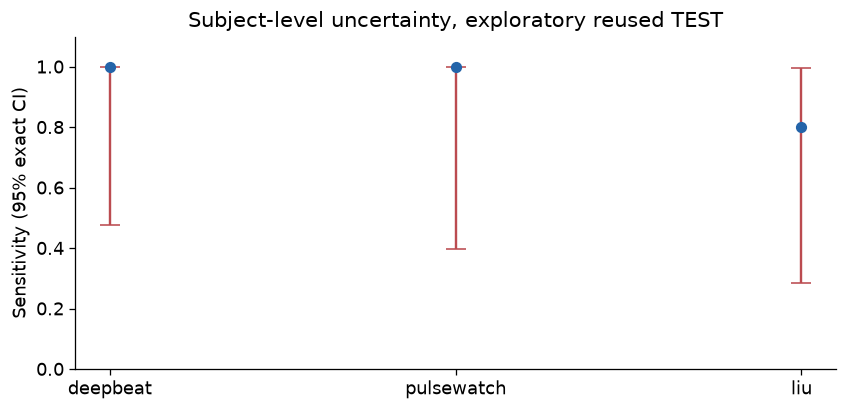

PosixPath('/home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T060119_214248Z/04_subject_sensitivity_exact_ci.png')

In [6]:
ci=csv(A+'global_rule_v2_exact_subject_ci.csv');sel=ci[ci.metric.eq('Sensitivity')].set_index('dataset').loc[['deepbeat','pulsewatch','liu']].reset_index();display(sel)
y=sel.point_estimate.to_numpy();lo=y-sel.exact_95_low.to_numpy();hi=sel.exact_95_high.to_numpy()-y
fig,ax=plt.subplots(figsize=(7.5,3.7));ax.errorbar(sel.dataset,y,yerr=[lo,hi],fmt='o',capsize=6,color=BLUE,ecolor=RED);ax.set_ylim(0,1.1);ax.set_ylabel('Sensitivity (95% exact CI)');ax.set_title('Subject-level uncertainty, exploratory reused TEST');figure(fig,'04_subject_sensitivity_exact_ci')

## 6. Calibration: Platt analysis-only
Không gọi đường reliability curve là thực nghiệm thực nếu chỉ có bảng tổng hợp. So sánh Brier DEV đủ để giải thích tại sao giữ raw probability; kết quả reused TEST có thể khác.

method,PLATT_OOF,RAW
dataset,,
deepbeat,0.121428,0.112268
pulsewatch,0.030398,0.028812
liu,0.043195,0.043037
POOLED,0.047103,0.044237


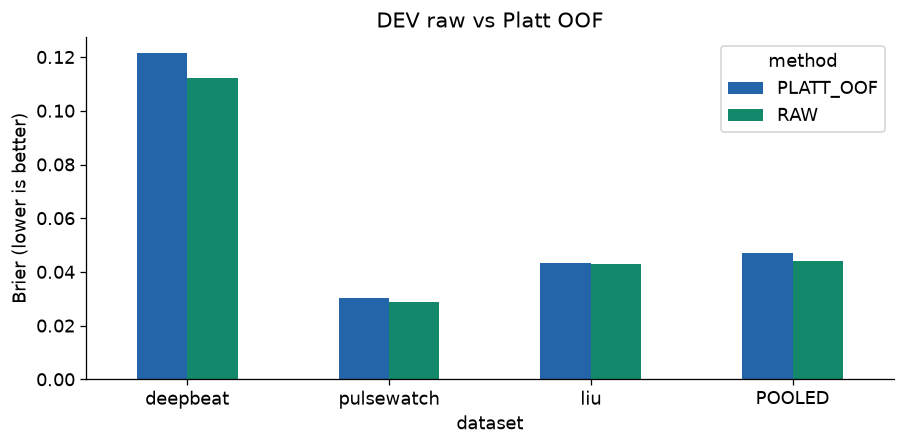

Raw is primary; Platt only an analysis artifact.


In [7]:
cal=csv(A+'calibration_summary.csv');d=cal[cal.split.eq('DEV') & cal.dataset.isin(['deepbeat','pulsewatch','liu','POOLED'])];wide=d.pivot(index='dataset',columns='method',values='Brier').reindex(['deepbeat','pulsewatch','liu','POOLED']);display(wide)
fig,ax=plt.subplots(figsize=(8,4));wide.plot.bar(ax=ax,color=[BLUE,GREEN]);ax.set_ylabel('Brier (lower is better)');ax.set_title('DEV raw vs Platt OOF');ax.tick_params(axis='x',rotation=0);figure(fig,'05_dev_calibration_brier')
assert freeze['probability_output']['primary']=='raw meta_probability';print('Raw is primary; Platt only an analysis artifact.')

## 7. Provenance + SHA256 gate
`locked_inputs_SHA256.txt` bao gồm model 1.88 GB và local prediction CSVs không có trong git. Mặc định kiểm tra hash các file nhỏ hiện diện; file lớn chỉ hash khi `HEALTHSENSE_HASH_LARGE=1`, để không vô tình tốn thời gian.

In [8]:
checksum_file=source(A+'locked_inputs_SHA256.txt');entries=[]
for line in checksum_file.read_text().splitlines():
    if not line.strip():continue
    expected,rel=line.split(maxsplit=1);p=ROOT/rel.strip();exists=p.is_file();size=p.stat().st_size if exists else None
    if exists and (size<=100*1024*1024 or __import__('os').getenv('HEALTHSENSE_HASH_LARGE')=='1'):
        observed=sha256(p);state='PASS' if observed==expected else 'FAIL_SHA256'
        if state!='PASS':raise ValueError('Mismatch for '+str(p))
    else:state='MISSING' if not exists else 'DEFERRED_LARGE_HASH'
    entries.append({'file':rel,'exists':exists,'bytes':size,'sha_state':state,'expected_sha256':expected})
gate=pd.DataFrame(entries);table(gate,'06_artifact_sha_gate')
assert meta['features']==freeze['feature_schema']['features'];print('Research model metadata sha256:',meta['sha256']);print('Do not assert deployment parity without AI Service runtime proof.')

,file,exists,bytes,sha_state,expected_sha256
0,models/multidomain/healthsense_af_v6c_stacking...,True,1876995235,PASS,e27370c51c8bbaf624abcbdabae40af5528d28bb2bd9e9...
1,experiments/08_v6_locked_protocol/artifacts/de...,True,766963,PASS,deb1f0cc13803c951718b551d9187245202118cb1e5340...
2,experiments/08_v6_locked_protocol/artifacts/de...,True,263510,PASS,32addb6b03358d203d197d0752253e793f05cb0f548ae9...
3,experiments/08_v6_locked_protocol/artifacts/li...,True,171757,PASS,aa7ca106cc0b9b2d5ef725c78ca5c3342ab719f8b8ac20...
4,experiments/08_v6_locked_protocol/artifacts/li...,True,162911,PASS,83d0dfb2e51bf44deed5bddd37ed45fa7c15f7dbae6bde...
5,experiments/08_v6_locked_protocol/artifacts/pu...,True,4177101,PASS,8858ecd22c01b55f8535947635d3d7563ff9457f545afa...
6,experiments/08_v6_locked_protocol/artifacts/pu...,True,7309630,PASS,d1321b230bab39296879ccd11bc0fd5b57f2bcc8f66628...


Research model metadata sha256: e27370c51c8bbaf624abcbdabae40af5528d28bb2bd9e9249d1d5bf9cbb9b77c
Do not assert deployment parity without AI Service runtime proof.


## 8. Bằng chứng hiện có vs giới hạn
Historical/exploratory artifacts nằm trong `deprecated_exploratory_artifacts.csv` và không được đổi nhãn thành confirmatory. Nhóm chưa có ECG-linked clinical validation từ thiết bị nguyên mẫu.

In [9]:
deprecated=csv(A+'deprecated_exploratory_artifacts.csv');display(deprecated)
statuses=freeze['external_validation'];display(pd.DataFrame([{'evidence':'Reused subject-held-out tests','status':freeze['evaluation_policy']['current_subject_tests']},{'evidence':'LODO','status':freeze['evaluation_policy']['LODO']},{'evidence':'Temporal rule','status':freeze['subject_alert_rule']['status']},{'evidence':'MIMIC-III-Ext-PPG','status':statuses['MIMIC_III_Ext_PPG']},{'evidence':'TriggersAF','status':statuses['TriggersAF']},{'evidence':'AI Service runtime parity','status':'NOT ESTABLISHED BY THIS RESEARCH REPO'}]))
print('Freeze instruction:',freeze['development_status'])

,artifact,status,reason
0,v6h_selected_operating_points.csv,DEPRECATED_FOR_CONFIRMATORY_REPORTING,Per-dataset operating points were selected aft...
1,v6_final_thesis_table.csv,DEPRECATED_FOR_CONFIRMATORY_REPORTING,Contains test-tuned V6H subject-level operatin...
2,v6_temporal_comparison_final.csv,HISTORICAL_EXPLORATORY,Includes V6F pooled configuration-union evalua...
3,v6_generalization_summary.csv,HISTORICAL_PROVENANCE_WARNING,Earlier summary may contain obsolete MIMIC-III...


,evidence,status
0,Reused subject-held-out tests,REUSED_SUBJECT_HELD_OUT_BENCHMARK
1,LODO,RETROSPECTIVE_DOMAIN_GENERALIZATION
2,Temporal rule,EXPLORATORY_CANDIDATE_FOR_SEALED_VALIDATION
3,MIMIC-III-Ext-PPG,PENDING_ACCESS_NOT_USED
4,TriggersAF,PENDING_ACCESS_NOT_USED
5,AI Service runtime parity,NOT ESTABLISHED BY THIS RESEARCH REPO


Freeze instruction: STOP MODEL TUNING ON CURRENT BENCHMARKS


In [10]:
manifest('03_Temporal_Calibration_and_Freeze', ['DEV-only selected temporal rule; prior reused TEST inspection means exploratory','Never edit original predictions/model during defense visualization','No production AI Service access in repository','Do not retrain or retune from these notebooks'])

Nguồn và checksum: /home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T060119_214248Z/03_Temporal_Calibration_and_Freeze_input_manifest.json
Biểu đồ: 5 | thư mục: /home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T060119_214248Z


PosixPath('/home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T060119_214248Z/03_Temporal_Calibration_and_Freeze_input_manifest.json')